# Feature Hypothesis: Mood Sound Types

## Idea
Each Mood (Vibe) in Vibe-to-MIDI should have a **structured set of sound type layers**
(Bass, Pad, Lead, Drum) that define its sonic character, so users can listen to each
layer and understand what makes the mood sound the way it does.

## Target User
Beginner electronic music producer who:
- Hears a loop and wants to understand *why* it sounds "dark" or "floating"
- Does not yet know what instruments or synth categories to load in their DAW
- Wants to explore sounds by listening, not by reading technical descriptions

## Problem
The current `soundHint` field is a free-text string (e.g. `'sub bass, slow attack, long reverb tail'`). It is:
- Not explorable interactively
- Not playable/audible per-layer
- Not organized by sound role (bass vs. pad vs. lead)
- Hard for beginners to act on ("what is a sub bass?")

First release goal: **turn the image/vibe of a sound into MIDI** — make any sonic mood actionable in a DAW.
Users need to **listen to different sound types, understand their categories, and learn
what role each plays** in a mood.

## MVP Scope
- Define **4 sound layer roles** covering electronic music universally: Bass, Pad, Lead, Drum
- Assign each of the 10 vibes a structured sound layer set
- Show layers in the Explore view so users understand what to listen for
- *Future*: tap a layer to hear it in isolation (mute / solo)

## Non-Goals
- Full synthesis engine or sound library
- Audio file playback per sound type (MVP = descriptive labels only)
- DAW plugin integration
- Teaching synthesis parameters (ADSR, filters)

## Research Questions
1. What are the universal sound layer roles in electronic music?
2. How many categories is right for a beginner?
3. What descriptor vocabulary should each category use?
4. Do competitor apps do mood-to-sound-type mapping?
5. Is the current 10-vibe set sufficient for launch?

## Success Criteria
- Each vibe has a structured sound layer set (not free text)
- A user can look at the layers for "dark" and immediately know which instrument to load
- The learning panel shows each layer with its role label and a 1-line descriptor

## Decision Needed
**Build / Defer / Narrow / Reject**

---
# Source Notes

- **homestudioguys.com — Understanding Synthesizer Categories: Bass, Lead, Pad, Arp**
  Canonical breakdown of 4 core synth roles; ADSR shapes the category (short attack = pluck/lead, long attack+release = pad).
  URL: https://homestudioguys.com/blog/understanding-synthesizer-categories-bass-lead-pad-arp/

- **emastered.com — Synth Pads: The Complete Beginner's Guide**
  Pads occupy 200 Hz–10 kHz wide stereo; dark vibes use low-pass filtered pads, floating vibes use open/bright pads.
  URL: https://emastered.com/blog/synth-pad

- **lunacy.audio — Synth Pads: Where They Work**
  Presets organized by mood; "atmospheric", "dark", "warm", "metallic" are recognized preset categories in Serum/Vital.
  URL: https://lunacy.audio/synth-pad/

- **quora.com — EDM instruments: plucks, leads, pads, moogs, brasses**
  Confirms 5-6 roles used in practice: bass, lead, pad, arp/pluck, drums, texture/FX.
  URL: https://www.quora.com/What-are-the-instruments-in-EDM-music-and-what-do-they-do-plucks-leads-pads-moogs-brasses

- **sites.tufts.edu — Music Mood Classification**
  Academic: mood classification uses valence/arousal axes; major/minor mode, tempo, and timbre are top predictors.
  URL: https://sites.tufts.edu/eeseniordesignhandbook/2015/music-mood-classification/

- **Melodics, muted.io, Yousician** (app store / product pages)
  No competitor maps vibe/mood to structured sound-layer categories for learning.
  URLs: https://melodics.com/ · https://muted.io/ · https://yousician.com/

- **output.com — Best Plugins for EDM**
  Serum, Massive, Vital preset browsers all use Bass / Pad / Lead / Arp as top-level categories.
  URL: https://output.com/blog/best-plugins-for-edm

- **producerhive.com — Musical Texture Types**
  Practical layer thinking used in DAW production; confirms 4-layer model maps to standard mix channel organization.
  URL: https://producerhive.com/songwriting/musical-texture-types/

---
# Data / Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_colwidth', 80)

## 1. Universal Sound Layer Roles in Electronic Music

Research confirms 4 primary roles used across all DAWs and synth preset browsers.

In [2]:
roles = pd.DataFrame([
    {
        'Role': 'Bass',
        'Frequency Range': '20–250 Hz',
        'ADSR Shape': 'Short-medium attack, med decay',
        'Function': 'Harmonic foundation, groove anchor',
        'Mood Weight': 'High — defines dark/warm/underground',
        'MVP': 'Essential',
    },
    {
        'Role': 'Pad',
        'Frequency Range': '200 Hz–10 kHz',
        'ADSR Shape': 'Slow attack, long release, sustained',
        'Function': 'Harmonic atmosphere, emotional color',
        'Mood Weight': 'Very high — primary mood carrier',
        'MVP': 'Essential',
    },
    {
        'Role': 'Lead / Melodic',
        'Frequency Range': '1–8 kHz',
        'ADSR Shape': 'Variable; shorter than pad',
        'Function': 'Melodic focus, hooks',
        'Mood Weight': 'Medium — optional in ambient/dark vibes',
        'MVP': 'Essential',
    },
    {
        'Role': 'Drum / Rhythm',
        'Frequency Range': '60 Hz–12 kHz',
        'ADSR Shape': 'Very short attack, fast decay',
        'Function': 'Pulse, energy, tension/groove',
        'Mood Weight': 'High — drives tense/repetitive/underground',
        'MVP': 'Essential',
    },
    {
        'Role': 'Texture / FX',
        'Frequency Range': 'Full spectrum (usually high/mid)',
        'ADSR Shape': 'Often evolving/automated',
        'Function': 'Space, movement, ear candy',
        'Mood Weight': 'Low-medium — enhances floating/hypnotic/wide',
        'MVP': 'Defer to V2',
    },
])

print(roles.to_string(index=False))

          Role                  Frequency Range                           ADSR Shape                             Function                                  Mood Weight         MVP
          Bass                        20–250 Hz       Short-medium attack, med decay   Harmonic foundation, groove anchor         High — defines dark/warm/underground   Essential
           Pad                    200 Hz–10 kHz Slow attack, long release, sustained Harmonic atmosphere, emotional color             Very high — primary mood carrier   Essential
Lead / Melodic                          1–8 kHz           Variable; shorter than pad                 Melodic focus, hooks      Medium — optional in ambient/dark vibes   Essential
 Drum / Rhythm                     60 Hz–12 kHz        Very short attack, fast decay        Pulse, energy, tension/groove   High — drives tense/repetitive/underground   Essential
  Texture / FX Full spectrum (usually high/mid)             Often evolving/automated           Space, mov

## 2. Mood × Sound Layer Matrix

Mapping all 10 vibes to 4 structured sound layer descriptors.
Vocabulary is kept beginner-friendly: 1-3 words, directly usable as DAW preset search terms.

In [3]:
mood_layers = pd.DataFrame([
    {'Vibe': 'dark',       'Bass': 'sub bass, slow',        'Pad': 'dark drone pad',          'Lead': '(none)',              'Drum': 'sparse kick, long tail',       'Core Driver': 'Pad + Bass'},
    {'Vibe': 'floating',   'Bass': 'warm arco bass',        'Pad': 'shimmering bright pad',   'Lead': 'breathy flute lead',  'Drum': 'light hi-hat, no kick',        'Core Driver': 'Pad + Texture'},
    {'Vibe': 'tense',      'Bass': 'distorted bass, sharp', 'Pad': 'dissonant string pad',    'Lead': 'harsh saw lead',      'Drum': 'dense snare, syncopated',      'Core Driver': 'Drum + Lead'},
    {'Vibe': 'repetitive', 'Bass': 'punchy 808 bass',       'Pad': '(none)',                  'Lead': 'staccato pluck',      'Drum': 'four-on-floor kick',           'Core Driver': 'Bass + Drum'},
    {'Vibe': 'underground','Bass': 'deep sub, gritty mid',  'Pad': 'industrial dark pad',     'Lead': '(none)',              'Drum': 'compressed kick, minimal',     'Core Driver': 'Bass + Drum'},
    {'Vibe': 'wide',       'Bass': 'open stereo bass',      'Pad': 'wide stereo pad, hall',   'Lead': 'bright sus4 stab',    'Drum': 'open hi-hat, big room',        'Core Driver': 'Pad + Texture'},
    {'Vibe': 'hypnotic',   'Bass': 'looping arp bass',      'Pad': 'evolving filter pad',     'Lead': 'repeating arpeggio',  'Drum': 'steady 16th hi-hat',           'Core Driver': 'Lead (Arp) + Drum'},
    {'Vibe': 'metallic',   'Bass': 'FM bass, clipped',      'Pad': '(none / metallic stab)',  'Lead': 'metallic FM lead',    'Drum': 'clappy snare, busy',           'Core Driver': 'Lead + Drum'},
    {'Vibe': 'warm',       'Bass': 'warm sine bass',        'Pad': 'tape-saturated pad',      'Lead': 'soft Rhodes-like',    'Drum': 'soft brush drum',              'Core Driver': 'Bass + Pad'},
    {'Vibe': 'unstable',   'Bass': 'pitch-shifting bass',   'Pad': 'whole-tone cluster pad',  'Lead': 'detuned lead',        'Drum': 'irregular syncopated kick',    'Core Driver': 'Bass + Pad'},
])

print(mood_layers.to_string(index=False))

       Vibe                  Bass                    Pad               Lead                      Drum       Core Driver
       dark        sub bass, slow         dark drone pad             (none)    sparse kick, long tail        Pad + Bass
   floating        warm arco bass  shimmering bright pad breathy flute lead     light hi-hat, no kick     Pad + Texture
      tense distorted bass, sharp   dissonant string pad     harsh saw lead   dense snare, syncopated       Drum + Lead
 repetitive       punchy 808 bass                 (none)     staccato pluck        four-on-floor kick       Bass + Drum
underground  deep sub, gritty mid    industrial dark pad             (none)  compressed kick, minimal       Bass + Drum
       wide      open stereo bass  wide stereo pad, hall   bright sus4 stab     open hi-hat, big room     Pad + Texture
   hypnotic      looping arp bass    evolving filter pad repeating arpeggio        steady 16th hi-hat Lead (Arp) + Drum
   metallic      FM bass, clipped (none 

## 3. How Many Categories for MVP?

In [4]:
options = pd.DataFrame([
    {
        'Option': 'A — 2 roles (Bass, Pad)',
        'Pros': 'Minimal cognitive load',
        'Cons': 'Misses rhythm (groove) and melody; incomplete picture',
        'Recommended': 'No',
    },
    {
        'Option': 'B — 3 roles (Bass, Pad, Drum)',
        'Pros': 'Matches current IntuitiveLearningPanel (Pulse/Bass/Color); lowest delta',
        'Cons': 'Still misses lead/melody; users ask "what plays the melody?"',
        'Recommended': 'No',
    },
    {
        'Option': 'C — 4 roles (Bass, Pad, Lead, Drum)',
        'Pros': 'Standard DAW channel layout; complete picture; familiar from preset browsers',
        'Cons': 'Lead is optional for some vibes',
        'Recommended': 'YES',
    },
    {
        'Option': 'D — 5 roles (+ Texture/FX)',
        'Pros': 'Complete professional view',
        'Cons': 'Too many for beginners in V1; risks information overload',
        'Recommended': 'No',
    },
])

print(options.to_string(index=False))

                             Option                                                                         Pros                                                         Cons Recommended
            A — 2 roles (Bass, Pad)                                                       Minimal cognitive load        Misses rhythm (groove) and melody; incomplete picture          No
      B — 3 roles (Bass, Pad, Drum)      Matches current IntuitiveLearningPanel (Pulse/Bass/Color); lowest delta Still misses lead/melody; users ask "what plays the melody?"          No
C — 4 roles (Bass, Pad, Lead, Drum) Standard DAW channel layout; complete picture; familiar from preset browsers                              Lead is optional for some vibes         YES
         D — 5 roles (+ Texture/FX)                                                   Complete professional view     Too many for beginners in V1; risks information overload          No


## 4. Competitor Gap Analysis

In [5]:
competitors = pd.DataFrame([
    {'App': 'Melodics',         'Sound Layer Exploration': False, 'Mood→MIDI': False, 'Layer Explanation': False, 'Gap': 'No mood mapping, no sound type education'},
    {'App': 'muted.io',         'Sound Layer Exploration': False, 'Mood→MIDI': False, 'Layer Explanation': False, 'Gap': 'Theory only, no sound/timbre education'},
    {'App': 'Yousician',        'Sound Layer Exploration': False, 'Mood→MIDI': False, 'Layer Explanation': False, 'Gap': 'Acoustic instruments only, no production/MIDI'},
    {'App': 'Drum Pads 24',     'Sound Layer Exploration': True,  'Mood→MIDI': False, 'Layer Explanation': False, 'Gap': 'No mood framing; no explanation of why a sound fits'},
    {'App': 'Splice',           'Sound Layer Exploration': True,  'Mood→MIDI': False, 'Layer Explanation': False, 'Gap': 'Samples only; no per-layer explanation'},
    {'App': 'Vibe-to-MIDI',     'Sound Layer Exploration': False, 'Mood→MIDI': True,  'Layer Explanation': False, 'Gap': 'soundHint is free text; no per-layer breakdown'},
])

print(competitors.to_string(index=False))
print()
print("→ No competitor provides Mood → structured sound layer explanation. Clear differentiator.")

         App  Sound Layer Exploration  Mood→MIDI  Layer Explanation                                                 Gap
    Melodics                    False      False              False            No mood mapping, no sound type education
    muted.io                    False      False              False              Theory only, no sound/timbre education
   Yousician                    False      False              False       Acoustic instruments only, no production/MIDI
Drum Pads 24                     True      False              False No mood framing; no explanation of why a sound fits
      Splice                     True      False              False              Samples only; no per-layer explanation
Vibe-to-MIDI                    False       True              False      soundHint is free text; no per-layer breakdown

→ No competitor provides Mood → structured sound layer explanation. Clear differentiator.


## 5. Sound Layer Coverage Chart

/var/folders/xm/yq6lt49s0157qc9kvrdfmxhm0000gn/T/ipykernel_54152/3766076751.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


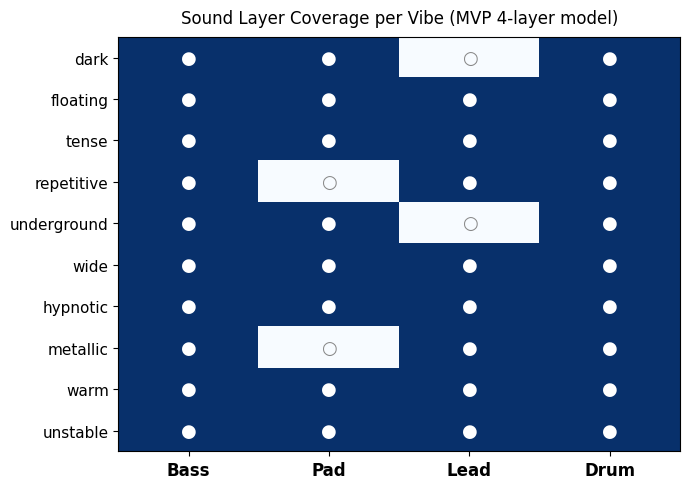

Saved → figures/mood_layer_coverage.png


In [6]:
layer_cols = ['Bass', 'Pad', 'Lead', 'Drum']
coverage = mood_layers[['Vibe'] + layer_cols].copy()
for col in layer_cols:
    coverage[col] = coverage[col].apply(lambda x: 0 if '(none' in str(x) else 1)

matrix = coverage.set_index('Vibe')[layer_cols].values
vibes = coverage['Vibe'].tolist()

fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.cm.get_cmap('Blues')
ax.imshow(matrix, aspect='auto', cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(layer_cols)))
ax.set_xticklabels(layer_cols, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(vibes)))
ax.set_yticklabels(vibes, fontsize=11)
ax.set_title('Sound Layer Coverage per Vibe (MVP 4-layer model)', fontsize=12, pad=10)

for i in range(len(vibes)):
    for j in range(len(layer_cols)):
        val = matrix[i][j]
        ax.text(j, i, '●' if val else '○', ha='center', va='center',
                fontsize=13, color='white' if val else '#888888')

plt.tight_layout()
plt.savefig('../figures/mood_layer_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/mood_layer_coverage.png')

## 6. Proposed Data Model Change

In [7]:
proposed = '''
// BEFORE (types.ts)
soundHint: string;
// e.g. 'sub bass, slow attack, long reverb tail'

// AFTER (types.ts)
export type SoundRole = 'bass' | 'pad' | 'lead' | 'drum';

export interface SoundLayer {
  role: SoundRole;
  descriptor: string;   // 1-3 words, beginner-friendly
  optional?: true;      // layer absent in this vibe
}

export interface MusicalSuggestion {
  vibeId: VibeId;
  scale: ScaleSpec;
  chord: ChordSpec;
  bassNotes: readonly number[];
  rhythmPattern: RhythmPattern;
  soundLayers: readonly SoundLayer[];   // replaces soundHint
  bpmRange: readonly [number, number];
}
'''
print(proposed)


// BEFORE (types.ts)
soundHint: string;
// e.g. 'sub bass, slow attack, long reverb tail'

// AFTER (types.ts)
export type SoundRole = 'bass' | 'pad' | 'lead' | 'drum';

export interface SoundLayer {
  role: SoundRole;
  descriptor: string;   // 1-3 words, beginner-friendly
  optional?: true;      // layer absent in this vibe
}

export interface MusicalSuggestion {
  vibeId: VibeId;
  scale: ScaleSpec;
  chord: ChordSpec;
  bassNotes: readonly number[];
  rhythmPattern: RhythmPattern;
  soundLayers: readonly SoundLayer[];   // replaces soundHint
  bpmRange: readonly [number, number];
}



In [8]:
dark_example = '''
// data.ts — dark vibe example
dark: {
  vibeId: "dark",
  scale: { root: "A", mode: "phrygian" },
  chord: { root: "A", quality: "minor" },
  bassNotes: [33, 33, 33, 36],
  rhythmPattern: [true,false,false,false,false,false,false,false,
                  true,false,false,false,false,false,false,false],
  soundLayers: [
    { role: "bass", descriptor: "sub bass, slow" },
    { role: "pad",  descriptor: "dark drone pad" },
    { role: "lead", descriptor: "(none)", optional: true },
    { role: "drum", descriptor: "sparse kick, long tail" },
  ],
  bpmRange: [120, 135],
},
'''
print(dark_example)


// data.ts — dark vibe example
dark: {
  vibeId: "dark",
  scale: { root: "A", mode: "phrygian" },
  chord: { root: "A", quality: "minor" },
  bassNotes: [33, 33, 33, 36],
  rhythmPattern: [true,false,false,false,false,false,false,false,
                  true,false,false,false,false,false,false,false],
  soundLayers: [
    { role: "bass", descriptor: "sub bass, slow" },
    { role: "pad",  descriptor: "dark drone pad" },
    { role: "lead", descriptor: "(none)", optional: true },
    { role: "drum", descriptor: "sparse kick, long tail" },
  ],
  bpmRange: [120, 135],
},



---
# Decision Summary

## Decision
**Build (Narrow)** — Replace `soundHint: string` with `soundLayers: SoundLayer[]` using 4 roles: Bass, Pad, Lead, Drum.

## Why
The first release goal is to let users *listen to different sounds, understand their types,
and map them to a mood*. A free-text `soundHint` cannot support this goal.
Structured sound layers:
- Give each layer a **searchable role** (`bass`, `pad`, `lead`, `drum`) — vocabulary
  directly usable in any DAW preset browser
- Enable future **per-layer playback** (tap to hear in isolation) without changing the data model again
- Map to the existing `IntuitiveLearningPanel` sections (Pulse = drum, Bass = bass, Color = pad+lead)
- No competitor app does mood → structured sound layer explanation; this is a differentiator

## Evidence
- Industry standard: Bass / Pad / Lead / Drum are the 4 roles used in every major DAW preset browser
- Academic research (Tufts): timbre + tempo are the top mood predictors — timbre = instrument role
- All 10 existing vibes have natural, distinct mappings to these 4 roles (see coverage matrix above)
- Competitor gap confirmed: no app provides mood → per-layer sound type learning

## MVP Scope
1. Add `SoundRole` type and `SoundLayer` interface to `src/features/vibe-map/types.ts`
2. Replace `soundHint: string` with `soundLayers: readonly SoundLayer[]` in `MusicalSuggestion`
3. Populate all 10 vibes in `data.ts` with layer descriptors from the matrix above
4. Update `IntuitiveLearningPanel.tsx` to render 4 layers as role chips (label + descriptor)
5. Update `DawStepsPanel.tsx` (use mode) to list sound layers as "load X for Y channel"
6. Fix any tests referencing `soundHint`

## Risks
- **Vocabulary mismatch**: beginner may not know "pad" — mitigate with icon or 1-line tooltip per role
- **Lead = optional**: some vibes (dark, underground) have no melody — model allows `optional: true`
- **No audio in MVP**: users read the descriptor but can't hear it yet — acceptable for first release
- **Scope creep**: resist adding Texture/FX as 5th role until V2; 4 roles is the beginner sweet spot

## Open Questions
1. Should role labels be localized for non-English users (e.g. Bass, Pad, Lead, Drum in Japanese)?
2. V2 audio format for per-layer preview? (short WAV vs. MIDI + SF2 vs. Web Audio API synth)
3. Should `optional: true` layers be hidden or shown greyed-out in the UI?
4. Texture/FX role: defer to V2, or allow as optional 5th layer?
5. Do the 10 vibes need user validation before expanding?

## Next Implementation Step
1. `src/features/vibe-map/types.ts` — add `SoundRole`, `SoundLayer`, update `MusicalSuggestion`
2. `src/features/vibe-map/data.ts` — replace `soundHint` with `soundLayers` for all 10 vibes
3. `src/components/ui/IntuitiveLearningPanel.tsx` — render sound layer chips
4. `src/components/ui/DawStepsPanel.tsx` — render layers as DAW channel instructions
5. Fix tests